In [5]:
!pip install pacmap

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from pacmap import PaCMAP


In [7]:
# Загрузка данных
data = pd.read_csv('depression_treatment_efficiency.csv')

In [8]:
print("Размер данных:", data.shape)
print("Первые 5 строк:")
print(data.head())

Размер данных: (1000, 6)
Первые 5 строк:
   age  symptom_duration  sleep_quality  anxiety_level  life_events  \
0   56                 8              6              8            3   
1   46                 6              4              6            4   
2   32                 6              5              7            4   
3   25                 8              6              9            6   
4   38                 1              4              8            5   

   treatment_success  
0                  0  
1                  1  
2                  1  
3                  0  
4                  0  


In [9]:
X = data.drop('treatment_success', axis=1)
y = data['treatment_success']

In [10]:
# Разделение на обучающую и тестовую выборки (70% / 30%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [11]:
# Нормализация данных
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
global_model = LogisticRegression(max_iter=1000, random_state=42)
global_model.fit(X_train_scaled, y_train)
y_pred_global = global_model.predict(X_test_scaled)

=== Единая модель ===
Accuracy: 0.793

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.92      0.86       198
           1       0.79      0.54      0.64       102

    accuracy                           0.79       300
   macro avg       0.79      0.73      0.75       300
weighted avg       0.79      0.79      0.78       300

Confusion Matrix:


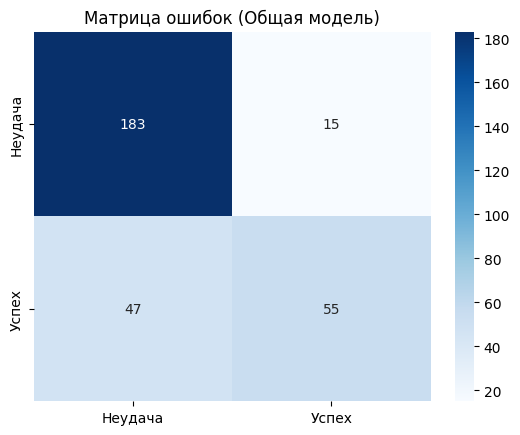

In [13]:
print("=== Единая модель ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_global):.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_global))
print("Confusion Matrix:")
cm_global = confusion_matrix(y_test, y_pred_global)
sns.heatmap(cm_global, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Неудача', 'Успех'],
            yticklabels=['Неудача', 'Успех'])
plt.title("Матрица ошибок (Общая модель)")
plt.show()